# Detección de Escala Espacial con el Correlograma de Moran's I
### *Ejemplo Rápido — Ecología de Paisajes*

---

Este cuaderno demuestra cómo:

1. Generar un **paisaje sintético** con una escala de autocorrelación espacial *conocida* (σ)
2. **Muestrear** puntos aleatorios sobre ese paisaje
3. **Calcular la I de Moran** a múltiples distancias de rezago (correlograma espacial)
4. **Visualizar** el correlograma
5. **Recuperar** la escala característica a partir de los datos — como si σ fuera desconocida

> **Idea clave:** El cruce por cero del correlograma revela la escala espacial incorporada en los datos. Esta es la lógica central de la detección de escala en ecología del paisaje.

## 0 · Instalación de dependencias

Solo es necesario la primera vez en un entorno Colab nuevo.

In [1]:
!pip install numpy scipy matplotlib libpysal esda --quiet

## 1 · Importaciones

In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

## 2 · Generar un paisaje con autocorrelación espacial

Partimos de **ruido blanco** (sin estructura espacial) y aplicamos un **filtro gaussiano** con desviación estándar σ (`SIGMA`).  
Este suavizado *inyecta* autocorrelación espacial a una escala característica conocida — el valor que luego queremos recuperar.

| Parámetro | Significado |
|-----------|-------------|
| `n` | Tamaño de la grilla (n × n celdas) |
| `SIGMA` | Escala característica en celdas de grilla — la "verdad" |

In [4]:
np.random.seed(42)
n = 100        # grilla de 100 × 100

# Ruido blanco — sin estructura espacial
white_noise = np.random.randn(n, n)

# El suavizado gaussiano crea autocorrelación espacial a escala SIGMA
SIGMA = 15     # celdas de grilla  ← esto es lo que queremos RECUPERAR más adelante
landscape = gaussian_filter(white_noise, sigma=SIGMA)

print(f"Forma del paisaje: {landscape.shape}")
print(f"Escala característica verdadera σ = {SIGMA} celdas")

Forma del paisaje: (100, 100)
Escala característica verdadera σ = 15 celdas


Hay 2 objetos:
 1. `white_noise`: una matriz de 100 x 100
 2. `landscape`: otra matriz que representa un paisaje con una correlacion conocida

## ¿Qué hace `gaussian_filter()`?
Imagina que tienes una imagen pixelada y la "desenfocas" suavemente con Photoshop. Eso es esencialmente lo que hace gaussian_filter: reemplaza el valor de cada celda por un promedio ponderado de sus vecinas, donde el peso de cada vecina depende de qué tan lejos está.
El peso sigue una curva gaussiana (campana de Gauss):

$$w(d)=e^{-\frac{d^2}{2\sigma^2}}$$

- Las celdas cercanas reciben mucho peso → contribuyen bastante al nuevo valor
- Las celdas lejanas reciben peso casi cero → apenas influyen

**El resultado**: celdas próximas terminan con valores similares → autocorrelación espacial.

## ¿Qué significa SIGMA?
SIGMA (σ) controla cuán ancha es esa campana — es decir, hasta qué distancia se "mezclan" los valores.

| $\sigma$ pequeño (ej. 3) | grande (ej. 20)|
|--|--|
| Campana estrecha| Campana ancha|
| Solo vecinas inmediatas influyen | Vecinas muy lejanas aún influyen|
| Parches pequeños, textura fina| Parches grandes, textura gruesa|
| Escala espacial corta | Escala espacial larga |

En el contexto del cuaderno, $\sigma$ **es literalmente la escala espacial característica del paisaje sintético** — la que después intentamos recuperar desde los datos de muestreo, como si no la conociéramos.

Regla práctica
A una distancia $d \approx 2\sigma$, el peso gaussiano ya es menor al 2% del máximo. Por eso el correlograma cruza cero aproximadamente en 2$\sigma$, no en $\sigma$ — la zona de influencia es más amplia que el núcleo mismo.

**Ejecuta las celdas abajo** con SIGMA_experiment = 5 y luego con SIGMA_experiment = 25 y observa cómo el cruce por cero se desplaza exactamente al doble de cada valor.



## 3 · Visualizar: ruido blanco vs. paisaje autocorrelacionado

Observa cómo el paisaje suavizado presenta parches amplios y coherentes — eso es autocorrelación espacial.  
El tamaño de los parches está directamente controlado por σ.

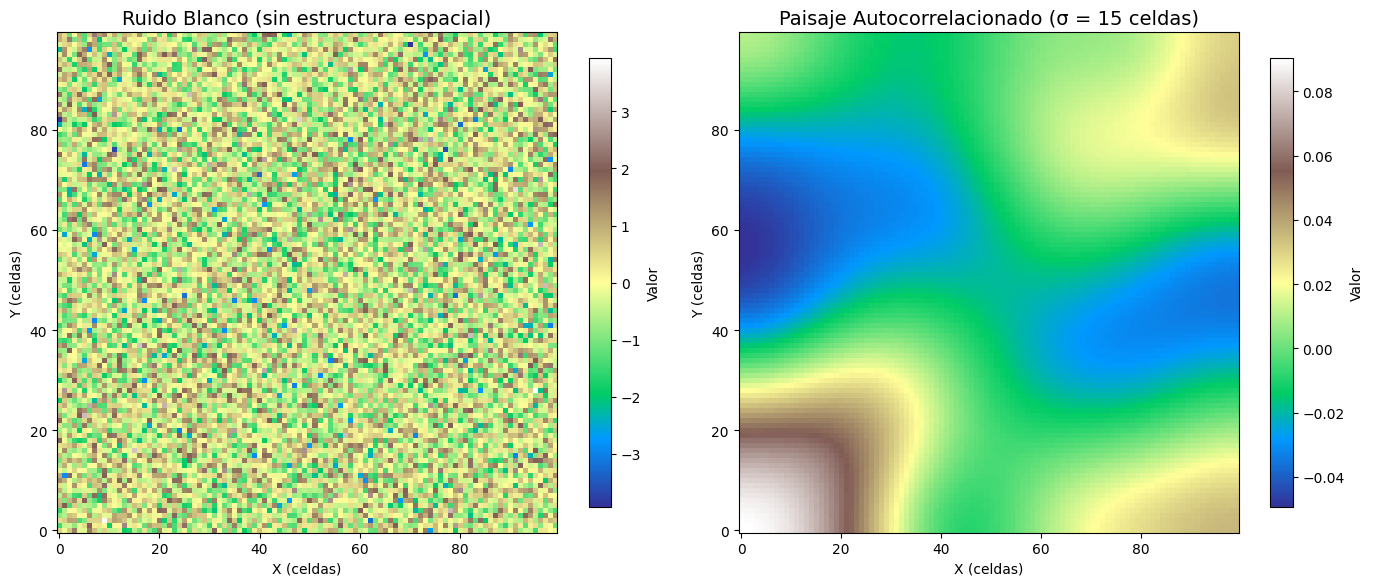

✓ Paisaje generado y graficado.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(white_noise, cmap='terrain', origin='lower')
axes[0].set_title('Ruido Blanco (sin estructura espacial)', fontsize=14)
axes[0].set_xlabel('X (celdas)')
axes[0].set_ylabel('Y (celdas)')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label='Valor')

im1 = axes[1].imshow(landscape, cmap='terrain', origin='lower')
axes[1].set_title(f'Paisaje Autocorrelacionado (σ = {SIGMA} celdas)', fontsize=14)
axes[1].set_xlabel('X (celdas)')
axes[1].set_ylabel('Y (celdas)')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label='Valor')

plt.tight_layout()
plt.savefig('01_comparacion_paisajes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Paisaje generado y graficado.")

## 4 · Muestrear puntos aleatorios del paisaje

En un estudio de campo real nunca se observa toda la grilla — se recogen *muestras puntuales*.  
Aquí extraemos `n_samples` ubicaciones aleatorias y registramos el valor del paisaje en cada una.

> **Nota sobre diseño muestral:** Si el grano de muestreo > σ, el patrón quedará completamente invisible.

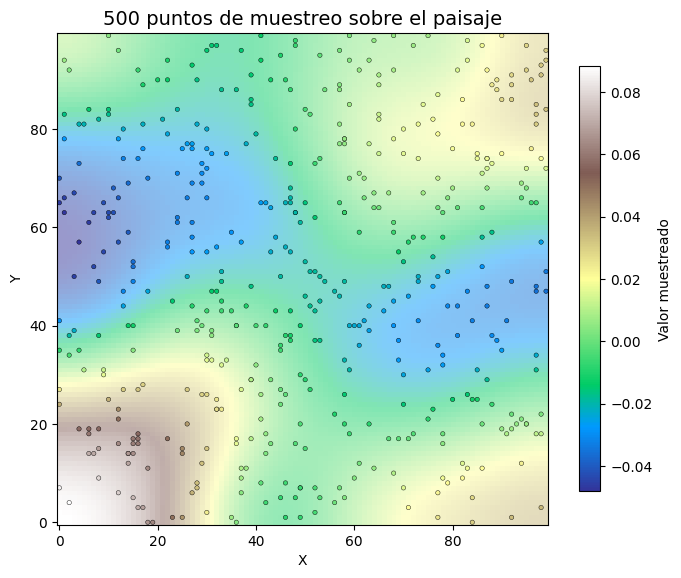

✓ 500 puntos muestreados.


In [16]:
n_samples = 500
xs = np.random.randint(0, n, n_samples)
ys = np.random.randint(0, n, n_samples)
values = np.array([landscape[x, y] for x, y in zip(xs, ys)])
coords  = np.column_stack([xs, ys])

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(landscape, cmap='terrain', origin='lower', alpha=0.5)
scatter = ax.scatter(ys, xs, c=values, cmap='terrain', s=10,
                     edgecolors='black', linewidths=0.3)
ax.set_title(f'{n_samples} puntos de muestreo sobre el paisaje', fontsize=14)
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.colorbar(scatter, ax=ax, shrink=0.8, label='Valor muestreado')
plt.tight_layout()
plt.savefig('02_ubicaciones_muestras.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ {n_samples} puntos muestreados.")

## 5 · Calcular la I de Moran a múltiples distancias de rezago

### ¿Qué es la I de Moran?

$$I = \frac{n}{W} \cdot \frac{\sum_i \sum_j w_{ij}(z_i - \bar{z})(z_j - \bar{z})}{\sum_i (z_i - \bar{z})^2}$$

| Símbolo | Significado |
|---------|-------------|
| $n$ | número de observaciones |
| $w_{ij}$ | peso espacial (1 si $i$ y $j$ son vecinos, 0 si no) |
| $W$ | suma de todos los pesos |
| $z_i$ | valor en la ubicación $i$ |

- **I ≈ +1** → autocorrelación positiva fuerte (valores similares se agrupan)  
- **I ≈ 0** → independencia espacial  
- **I ≈ −1** → patrón de tablero de ajedrez (vecinos con valores distintos)

### Estrategia: bandas anulares de rezago

En lugar de discos acumulativos, usamos **anillos delgados** `[d−2, d]` en cada rezago `d`.  
Esto aísla la contribución de cada distancia y produce un correlograma más limpio.

In [17]:
# Precalcular todas las distancias por pares (reutilizadas en todos los rezagos)
dists_all = cdist(coords, coords)

lag_centers   = np.arange(3, 50, 2)
morans_values = []
pair_counts   = []

mean_val   = np.mean(values)
deviations = values - mean_val
var_term   = np.sum(deviations**2)

print("Calculando la I de Moran a múltiples distancias de rezago...")
print(f"{'Rezago (celdas)':>16} {'I de Moran':>12} {'N pares':>10}")
print("-" * 40)

for d in lag_centers:
    # Banda anular: vecinos estrictamente entre d-2 y d
    W = (dists_all <= d) & (dists_all > d - 2) & (dists_all > 0)
    n_pairs = W.sum()

    if n_pairs < 10:
        morans_values.append(np.nan)
        pair_counts.append(n_pairs)
        continue

    numerator   = len(values) * np.sum(W * np.outer(deviations, deviations))
    denominator = n_pairs * var_term
    I = numerator / denominator

    morans_values.append(I)
    pair_counts.append(n_pairs)
    print(f"{d:>16.0f} {I:>12.4f} {n_pairs:>10}")

print("\n✓ Cálculo de la I de Moran completado.")

Calculando la I de Moran a múltiples distancias de rezago...
 Rezago (celdas)   I de Moran    N pares
----------------------------------------
               3       1.1142        580
               5       0.9791       1256
               7       0.9400       1482
               9       0.8709       2368
              11       0.8814       2646
              13       0.7479       3214
              15       0.7049       3746
              17       0.6295       4002
              19       0.5553       4638
              21       0.4341       4712
              23       0.3717       5136
              25       0.3035       5784
              27       0.2785       5792
              29       0.1763       5834
              31       0.1004       6294
              33       0.0353       6494
              35      -0.0052       7128
              37      -0.0571       6680
              39      -0.1328       7006
              41      -0.1421       6656
              43      -0.1756       7

## 6 · Graficar el correlograma espacial

El correlograma muestra cómo decae la similitud espacial con la distancia.  
Buscamos el **cruce por cero** — el rezago en el que la I de Moran cae a cero —  
que marca el límite de la autocorrelación espacial y estima la escala característica.

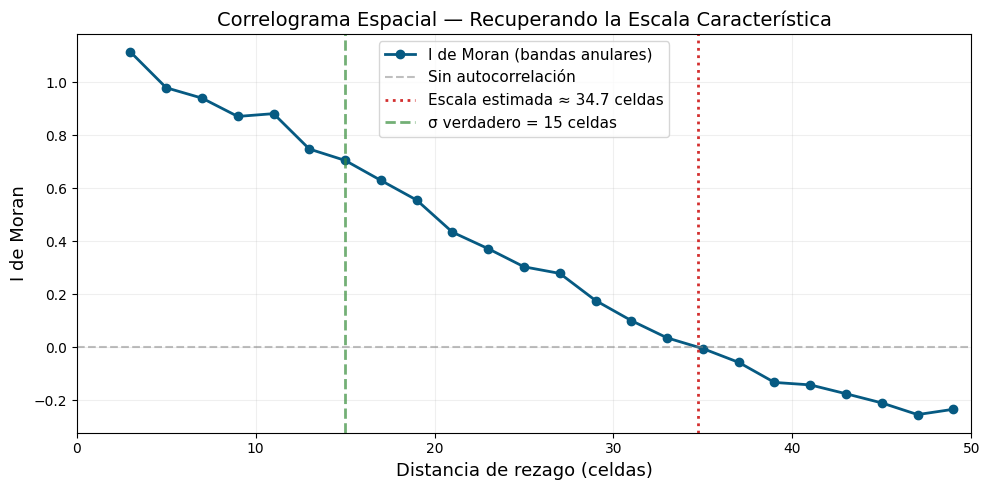

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(lag_centers, morans_values, 'o-', color='#065A82',
        markersize=6, linewidth=2, label="I de Moran (bandas anulares)")
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Sin autocorrelación')

# Estimar el cruce por cero mediante interpolación lineal
valid = [(d, m) for d, m in zip(lag_centers, morans_values) if not np.isnan(m)]
zero_crossing = None
for i in range(1, len(valid)):
    if valid[i-1][1] > 0 and valid[i][1] <= 0:
        d1, m1 = valid[i-1]
        d2, m2 = valid[i]
        zero_crossing = d1 + (0 - m1) * (d2 - d1) / (m2 - m1)
        break

if zero_crossing:
    ax.axvline(x=zero_crossing, color='#D32F2F', linestyle=':', linewidth=2,
               label=f'Escala estimada ≈ {zero_crossing:.1f} celdas')

ax.axvline(x=SIGMA, color='#388E3C', linestyle='--', linewidth=2, alpha=0.7,
           label=f'σ verdadero = {SIGMA} celdas')

ax.set_xlabel('Distancia de rezago (celdas)', fontsize=13)
ax.set_ylabel("I de Moran", fontsize=13)
ax.set_title('Correlograma Espacial — Recuperando la Escala Característica', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, 50)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('03_correlograma.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Resumen e Interpretación

In [19]:
print("=" * 60)
print("RESULTADOS")
print("=" * 60)
print(f"  Escala característica verdadera (σ):   {SIGMA} celdas")
if zero_crossing:
    print(f"  Escala estimada (cruce por cero):      {zero_crossing:.1f} celdas")
    print(f"  Error relativo:                        {abs(zero_crossing - SIGMA)/SIGMA * 100:.1f}%")

RESULTADOS
  Escala característica verdadera (σ):   15 celdas
  Escala estimada (cruce por cero):      34.7 celdas
  Error relativo:                        131.6%


### Conceptos clave

| Observación | Significado |
|-------------|-------------|
| **I de Moran > 0 a rezagos cortos** | Los puntos cercanos tienen valores similares → agrupamiento espacial |
| **I de Moran → 0 en la escala característica** | Los valores se vuelven espacialmente independientes |
| **Cruce por cero ≈ 2σ** | Esperado para suavizado gaussiano: el rango de autocorrelación supera el σ del núcleo |

### Implicaciones para el diseño muestral

- Si el **grano de muestreo > σ**, el patrón será completamente invisible  
- Si la **extensión espacial < σ**, detectarás tendencia en lugar de estructura  
- La *forma* del correlograma importa, no solo el valor exacto del cruce por cero

### En una aplicación real

**No se conoce** σ de antemano. El correlograma lo revela.  
Esta es la lógica central empleada en:
- Ecología del paisaje (detección de escala de parches)
- Geoestadística (ajuste de variogramas)
- Ecología de distribuciones de especies (rango de dependencia espacial)

## 8 · Extra: experimenta con distintas escalas 🔬

Cambia `SIGMA_experiment` y vuelve a ejecutar el cuaderno completo (Entorno de ejecución → Ejecutar todo) para observar cómo se desplaza el correlograma.

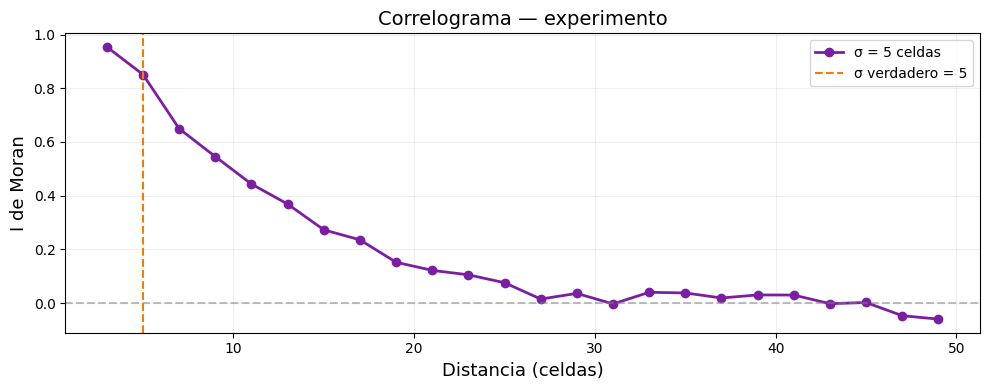

In [22]:
# ── Mueve esta "perilla" (cambia el valor) ───────────────────
SIGMA_experiment = 5   # prueba 5, 10, 20, 30 …
# ─────────────────────────────────────────────────────────────

landscape_exp = gaussian_filter(np.random.randn(n, n), sigma=SIGMA_experiment)
xs_e = np.random.randint(0, n, n_samples)
ys_e = np.random.randint(0, n, n_samples)
values_e   = np.array([landscape_exp[x, y] for x, y in zip(xs_e, ys_e)])
coords_e   = np.column_stack([xs_e, ys_e])
dists_e    = cdist(coords_e, coords_e)
dev_e      = values_e - np.mean(values_e)
var_e      = np.sum(dev_e**2)

mi_exp = []
for d in lag_centers:
    W = (dists_e <= d) & (dists_e > d - 2) & (dists_e > 0)
    np_ = W.sum()
    if np_ < 10:
        mi_exp.append(np.nan); continue
    mi_exp.append(len(values_e) * np.sum(W * np.outer(dev_e, dev_e)) / (np_ * var_e))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lag_centers, mi_exp, 'o-', color='#7B1FA2', linewidth=2,
        label=f"σ = {SIGMA_experiment} celdas")
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=SIGMA_experiment, color='#F57C00', linestyle='--',
           label=f'σ verdadero = {SIGMA_experiment}')
ax.set_xlabel('Distancia (celdas)', fontsize=13)
ax.set_ylabel("I de Moran", fontsize=13)
ax.set_title('Correlograma — experimento', fontsize=14)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()